In [28]:
from typing import TypedDict
import random
from langgraph.types import interrupt, Command
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

In [29]:
class State(TypedDict):
    user_prompt: str 
    code: str 
    latest_error: str 
    retry_count: int 
    hitl: str

llm = ChatOllama(model="llama3.1")

In [30]:
def generate_node(state: State) -> State:
    user_prompt = state.get("user_prompt", "")
    latest_error = state.get("latest_error", "")
    
    prompt_str = """
    You are a Python Developer with 10 years of experience.
    User request: {query}
    Previous Error (if any): {error}
    Rules: You only have to generate python code and nothing extra.
    """
    
    # Fix: Wrapped the raw string in a PromptTemplate to make it compatible with LCEL
    prompt = PromptTemplate.from_template(prompt_str)
    chain = prompt | llm | StrOutputParser()
    
    code = chain.invoke({"query": user_prompt, "error": latest_error})
    return {"code": code, "latest_error": ""}

In [31]:
def testing_node(state: State) -> State:
    # Fix: Safely initialized the counter to 0 for the first run
    current_retries = state.get("retry_count", 0)
    
    choice = random.random()
    if choice > 0.75:
        return {"latest_error": "PASS", "retry_count": current_retries + 1}
    return {"latest_error": "FAIL", "retry_count": current_retries + 1}

In [32]:
def router_condition(state: State) -> str:
    latest_error = state.get("latest_error", "")
    retry_count = state.get("retry_count", 0)
    
    if latest_error == "PASS":
        return END
    if latest_error == "FAIL":
        if retry_count < 3:
            return "generate"
        else:
            return "ask"

In [33]:
def ask_node(state: State) -> State:
    # Fix: Used single quotes around 'code' inside the f-string dictionary lookup
    decision = interrupt({
        "type": "approval", 
        "message": f"Are you satisfied with this code:\n\n{state.get('code', 'No Code')}\n\nType your answer.",
        "instructions": "When resuming, provide a dict: {'approval': 'yes'/'no'}"
    })
    return {"hitl": decision.get("approval", "no")}

def reset_node(state: State) -> State:
    return {"retry_count": 0, "latest_error": ""}

def route_hitl(state: State) -> str:
    hitl = state.get("hitl", "no").lower()
    if hitl == "no":
        return "reset"
    return END

In [34]:
builder = StateGraph(State)
checkpointer = InMemorySaver()

# Fix: Standardized node names so they perfectly match the edges
builder.add_node("generate", generate_node)
builder.add_node("test", testing_node)
builder.add_node("ask", ask_node)
builder.add_node("reset", reset_node)

builder.add_edge(START, "generate")

# After generation, always move directly to testing
builder.add_edge("generate", "test")

# After testing, evaluate the result to see if we loop, ask human, or finish
builder.add_conditional_edges("test", router_condition, {
    END: END,
    "generate": "generate",
    "ask": "ask"
})

# After the human intervenes, decide if we reset or finish
builder.add_conditional_edges("ask", route_hitl, {
    "reset": "reset",
    END: END
})
builder.add_edge("reset", "generate")

graph = builder.compile(checkpointer=checkpointer)

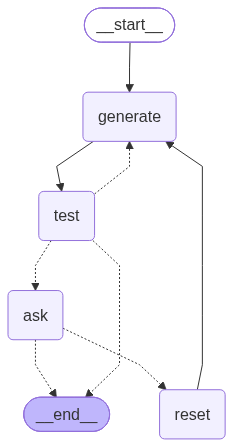

In [35]:
graph

In [36]:
config = {"configurable": {"thread_id": "dev_session_001"}}
initial_input = {"user_prompt": "Write a python script to calculate the Fibonacci sequence."}
print("--- STARTING GRAPH ---")
for event in graph.stream(initial_input, config=config):
    for node_name, state_update in event.items():
        print(f"Executed Node: '{node_name}'")
        if "retry_count" in state_update:
             print(f" -> Retry Count: {state_update['retry_count']} | Status: {state_update.get('latest_error')}")

current_state = graph.get_state(config)

if not current_state.next:
    print("\n✅ Graph finished successfully without human intervention!")
    print("\nFinal Code:")
    print(current_state.values.get("code"))
else:
    print(f"\n⏸️ GRAPH PAUSED AT NODE: {current_state.next[0]}")
    
    # Extract the code generated so far from the state
    current_code = current_state.values.get("code", "No code generated.")
    print(f"\n--- Code Pending Approval ---\n{current_code}\n-----------------------------")
    
    # 4. Provide Human Feedback and Resume
    # In a real app, this would be an API endpoint or a UI button click.
    # Here, we simulate the human rejecting the code to trigger the 'reset' node.
    human_decision = "no" 
    print(f"\nHuman decision: '{human_decision}' (Triggering reset...)")
    
    resume_data = {"approval": human_decision}
    
    print("\n--- RESUMING GRAPH ---")
    # Inject the resume_data using Command and stream the rest of the graph
    for event in graph.stream(Command(resume=resume_data), config=config):
        for node_name, state_update in event.items():
            print(f"Executed Node: '{node_name}'")
            if "retry_count" in state_update:
                 print(f" -> Retry Count: {state_update['retry_count']}")
                 
    print("\n🏁 Graph execution completed after human intervention.")

--- STARTING GRAPH ---
Executed Node: 'generate'
Executed Node: 'test'
 -> Retry Count: 1 | Status: FAIL
Executed Node: 'generate'
Executed Node: 'test'
 -> Retry Count: 2 | Status: PASS

✅ Graph finished successfully without human intervention!

Final Code:
def fibonacci(n):
    fib_sequence = [0, 1]
    while len(fib_sequence) < n:
        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])
    return fib_sequence[:n]

print(fibonacci(10))
